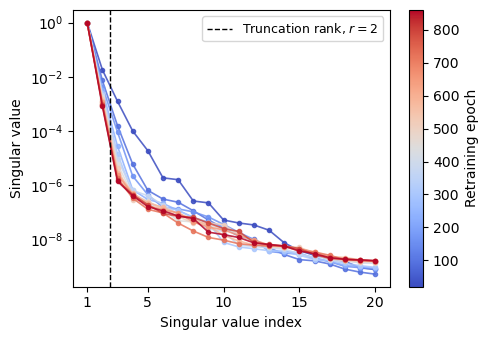

In [9]:
import numpy as np
import matplotlib.pyplot as plt

filename = 'sindy_sings.txt'
data = np.loadtxt(filename)  # (13, 20)
data /= data[:, 0:1]

# Retraining epochs: first at 20, then every 70
epochs = 20 + 70 * np.arange(data.shape[0])  # [20, 90, 160, ..., 860]

fig, ax = plt.subplots(figsize=(5, 3.5))

cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=epochs[0], vmax=epochs[-1])

for i, epoch in enumerate(epochs):
    ax.semilogy(
        np.arange(1, data.shape[1] + 1),
        data[i],
        marker='o',
        markersize=3,
        linewidth=1.2,
        color=cmap(norm(epoch)),
        alpha=0.85,
    )

# truncation line
ax.axvline(x=2.5, color='k', linestyle='--', linewidth=1.0, label=r'Truncation rank, $r = 2$')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Retraining epoch', fontsize=10)

ax.set_xlabel('Singular value index', fontsize=10)
ax.set_ylabel('Singular value', fontsize=10)
ax.set_xticks([1, 5, 10, 15, 20])
ax.legend(fontsize=9, loc='upper right')

fig.tight_layout()
fig.savefig('svd_spectrum.png', bbox_inches='tight', dpi=300)
plt.show()